# 04 — LoRA supervised fine-tuning of Qwen2.5-1.5B-Instruct

The main experiment. The same model notebook 03 prompts zero-shot is now fine-tuned with
LoRA to emit the intent name, using the **same prompt**, so the difference between the two
results is attributable to the weights and nothing else.

The question: does a parameter-efficient fine-tune of a 1.5B instruction model beat a fully
fine-tuned 110M encoder that was pretrained on Turkish?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alper4n/turkish-intent-llm/blob/main/notebooks/04_lora_qwen.ipynb)

> Needs a GPU runtime. In Colab: **Runtime → Change runtime type → T4 GPU**.

## 0. Setup

In [9]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/alper4n/turkish-intent-llm.git"
    if not Path("turkish-intent-llm").exists():
        !git clone -q $REPO_URL
    %cd turkish-intent-llm
    !pip install -q -U "transformers>=5.0,<6" "datasets>=3.0" "accelerate>=1.0" \
        "peft>=0.11" "pyyaml>=6.0"
    # Colab preinstalls torchao 0.10, and current peft refuses to import next to a
    # torchao below 0.16 instead of skipping the integration — get_peft_model raises
    # ImportError. Nothing in this repo quantises anything, so removing torchao is the
    # fix rather than chasing a compatible version, and it matches the environment the
    # notebook was tested in.
    !pip uninstall -q -y torchao

root = Path.cwd()
while not (root / "src").is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root:", root)

/content/turkish-intent-llm/turkish-intent-llm
repo root: /content/turkish-intent-llm/turkish-intent-llm


In [10]:
import json
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from peft import LoraConfig, get_peft_model
from transformers import (AutoModelForCausalLM, AutoTokenizer, Trainer,
                          TrainingArguments)

from src.compat import neutralize_peft_torchao_check
from src.data import load_splits, intent_labels
from src.metrics import compute_metrics
from src.prompting import build_system_prompt, generate_labels, parse_label, prepare_tokenizer
from src.sft import (IGNORE_INDEX, CompletionOnlyCollator, build_dataset,
                     build_example, cast_trainable_to_fp32)
from src.utils import describe_environment, load_config, save_results, set_seed

data_cfg = load_config(root / "configs" / "data.yaml")
cfg = load_config(root / "configs" / "lora_qwen.yaml")
SEED = data_cfg["seed"]
set_seed(SEED)

# The setup cell removes Colab's outdated torchao, which current peft refuses to load
# beside. This catches any session where that did not take effect — see src/compat.py.
_patched = neutralize_peft_torchao_check()
if _patched:
    print(f"applied peft/torchao compatibility shim to {_patched} references\n")

FIG_DIR = root / data_cfg["paths"]["figures_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

env = describe_environment()
DEVICE = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu")
env["device"] = DEVICE
GEN_BATCH = (cfg["generation"]["batch_size_cuda"] if DEVICE == "cuda"
             else cfg["generation"]["batch_size"])
env["generation_batch_size"] = GEN_BATCH
print(json.dumps(env, indent=2))

if DEVICE != "cuda":
    print("\n!! No GPU detected. Training a 1.5B model needs one — "
          "switch the runtime to T4 before continuing.")

{
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "torch": "2.11.0+cu128",
  "cuda_available": true,
  "gpu": "Tesla T4",
  "cuda_capability": "7.5",
  "bf16_runs": true,
  "bf16_native": false,
  "device": "cuda",
  "generation_batch_size": 16
}


## 1. Data

In [11]:
splits = load_splits(data_cfg["dataset"]["locale"],
                     cache_dir=root / data_cfg["dataset"]["cache_dir"])
LABELS = intent_labels(splits["train"])

tokenizer = prepare_tokenizer(AutoTokenizer.from_pretrained(cfg["model"]["name"]))
print(f"{len(LABELS)} intents | train {len(splits['train']):,} | test {len(splits['test']):,}")

60 intents | train 11,514 | test 2,974


### Loss is computed on the answer only

Every training sequence is the shared prompt plus a two- or three-token intent name. If the
loss covered the whole sequence, almost all of the gradient signal would go into
reproducing 300 tokens of boilerplate that are identical in every example. `src/sft.py`
masks the prompt with `-100` so the model is only ever scored on the part that varies.

In [12]:
example = build_example("yarın sabah yedide alarm kur", "alarm_set", LABELS, tokenizer)
supervised = [t for t, l in zip(example["input_ids"], example["labels"])
              if l != IGNORE_INDEX]

print(f"sequence length   : {len(example['input_ids'])} tokens")
print(f"supervised tokens : {len(supervised)}")
print(f"supervised content: {tokenizer.decode(supervised)!r}")
print(f"share of sequence : {len(supervised)/len(example['input_ids']):.1%}")

sequence length   : 301 tokens
supervised tokens : 3
supervised content: 'alarm_set<|im_end|>'
share of sequence : 1.0%


Worth being explicit about the cost: 99% of every training sequence is prompt. That is the
price of keeping the prompt identical to the zero-shot baseline, which is what makes the
comparison honest. A system built for deployment rather than for comparison would fine-tune
against a short prompt — once the weights carry the inventory, listing all 60 intents on
every call is wasted context.

In [13]:
train_ds = build_dataset(splits["train"], LABELS, tokenizer)
eval_ds = build_dataset(
    splits["validation"].sample(cfg["training"]["eval_sample_size"], random_state=SEED),
    LABELS, tokenizer)
collator = CompletionOnlyCollator(pad_token_id=tokenizer.pad_token_id)

lengths = [len(x) for x in train_ds["input_ids"]]
print(f"train sequences: {len(train_ds):,} | eval: {len(eval_ds):,}")
print(f"sequence length: mean {sum(lengths)/len(lengths):.0f}, max {max(lengths)}")

train sequences: 11,514 | eval: 500
sequence length: mean 304, max 350


## 2. Model and adapters

The base weights stay frozen in fp16; only the LoRA matrices train, and those are promoted
to fp32. Pure-fp16 optimizer states round small updates away — promoting the adapters costs
almost nothing because they are a fraction of the parameters, and it removes the usual
source of instability in fp16 LoRA runs.

In [14]:
model = AutoModelForCausalLM.from_pretrained(
    cfg["model"]["name"], dtype=getattr(torch, cfg["model"]["dtype"]))

lora_cfg = LoraConfig(
    r=cfg["lora"]["r"],
    lora_alpha=cfg["lora"]["alpha"],
    lora_dropout=cfg["lora"]["dropout"],
    target_modules=cfg["lora"]["target_modules"],
    task_type="CAUSAL_LM",
    bias="none",
)
model = get_peft_model(model, lora_cfg)
cast_trainable_to_fp32(model)

# Gradient checkpointing recomputes activations during backward. With a frozen base and
# only LoRA trainable, the inputs to a checkpointed block carry no grad, and the reentrant
# implementation then has nothing to backpropagate through. Marking the embedding output
# as requiring grad reconnects the graph; it is a no-op on the non-reentrant path.
if cfg["training"]["gradient_checkpointing"]:
    model.enable_input_require_grads()

model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"total parameters    : {total:,}")
print(f"trainable parameters: {trainable:,}  ({trainable/total:.2%})")
print(f"LoRA rank {cfg['lora']['r']}, alpha {cfg['lora']['alpha']}, "
      f"targets: {', '.join(cfg['lora']['target_modules'])}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

total parameters    : 1,562,179,072
trainable parameters: 18,464,768  (1.18%)
LoRA rank 16, alpha 32, targets: q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj


## 3. Training

In [15]:
tcfg = cfg["training"]
args = TrainingArguments(
    output_dir=str(root / cfg["output"]["checkpoint_dir"]),
    num_train_epochs=tcfg["num_train_epochs"],
    per_device_train_batch_size=tcfg["per_device_train_batch_size"],
    gradient_accumulation_steps=tcfg["gradient_accumulation_steps"],
    per_device_eval_batch_size=tcfg["per_device_eval_batch_size"],
    learning_rate=float(tcfg["learning_rate"]),
    weight_decay=tcfg["weight_decay"],
    warmup_steps=tcfg["warmup_steps"],
    lr_scheduler_type=tcfg["lr_scheduler_type"],
    max_grad_norm=tcfg["max_grad_norm"],
    gradient_checkpointing=tcfg["gradient_checkpointing"],
    eval_strategy="epoch",
    save_strategy="no",          # the adapter is saved once, after training
    logging_steps=tcfg["logging_steps"],
    disable_tqdm=True,
    fp16=(DEVICE == "cuda"),
    seed=SEED,
    data_seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=collator,
    processing_class=tokenizer,
)
steps = (len(train_ds) // (tcfg["per_device_train_batch_size"]
                           * tcfg["gradient_accumulation_steps"])
         * tcfg["num_train_epochs"])
print(f"optimizer steps: ~{steps} (effective batch "
      f"{tcfg['per_device_train_batch_size'] * tcfg['gradient_accumulation_steps']})")

optimizer steps: ~1438 (effective batch 16)


In [16]:
start = time.time()
train_result = trainer.train()
train_seconds = time.time() - start
print(f"\ntraining wall clock: {train_seconds/60:.1f} min")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


{'loss': '0.6923', 'grad_norm': '3.826', 'learning_rate': '9.8e-05', 'epoch': '0.06947'}
{'loss': '0.3744', 'grad_norm': '3.116', 'learning_rate': '0.000198', 'epoch': '0.1389'}
{'loss': '0.3153', 'grad_norm': '2.648', 'learning_rate': '0.0001993', 'epoch': '0.2084'}
{'loss': '0.3045', 'grad_norm': '1.636', 'learning_rate': '0.0001973', 'epoch': '0.2779'}
{'loss': '0.2652', 'grad_norm': '1.483', 'learning_rate': '0.000194', 'epoch': '0.3473'}
{'loss': '0.2601', 'grad_norm': '3.304', 'learning_rate': '0.0001893', 'epoch': '0.4168'}
{'loss': '0.2351', 'grad_norm': '2.677', 'learning_rate': '0.0001834', 'epoch': '0.4863'}
{'loss': '0.2291', 'grad_norm': '1.995', 'learning_rate': '0.0001764', 'epoch': '0.5557'}
{'loss': '0.2339', 'grad_norm': '1.04', 'learning_rate': '0.0001684', 'epoch': '0.6252'}
{'loss': '0.2224', 'grad_norm': '1.839', 'learning_rate': '0.0001593', 'epoch': '0.6947'}
{'loss': '0.2126', 'grad_norm': '2.05', 'learning_rate': '0.0001495', 'epoch': '0.7642'}
{'loss': '0.207

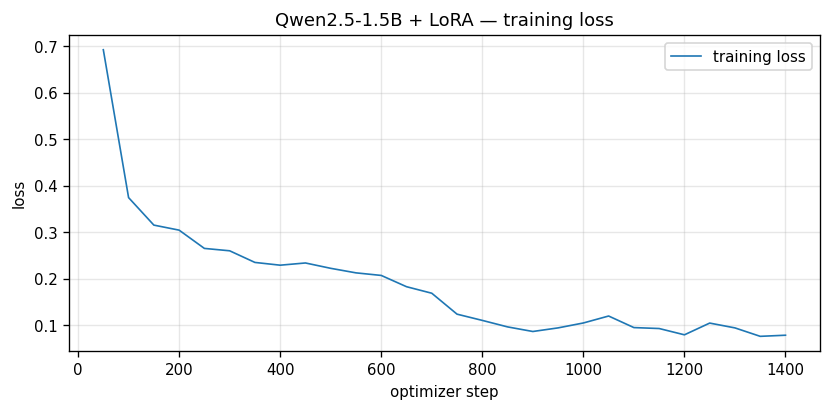

 epoch  eval_loss
   1.0     0.2013
   2.0     0.1575


In [17]:
history = pd.DataFrame(trainer.state.log_history)
train_log = history[history["loss"].notna()][["step", "loss"]] if "loss" in history else None
eval_log = (history[history["eval_loss"].notna()][["epoch", "eval_loss"]]
            if "eval_loss" in history else None)

fig, ax = plt.subplots(figsize=(7, 3.5))
if train_log is not None:
    ax.plot(train_log["step"], train_log["loss"], lw=1, label="training loss")
ax.set_xlabel("optimizer step")
ax.set_ylabel("loss")
ax.set_title("Qwen2.5-1.5B + LoRA — training loss")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "lora_training_loss.png", bbox_inches="tight")
plt.show()

if eval_log is not None:
    print(eval_log.round(4).to_string(index=False))

## 4. Test-set evaluation

Generation needs the KV cache, which gradient checkpointing switches off during training —
so both are restored before decoding, using exactly the same `generate_labels` and
`parse_label` as the zero-shot notebook.

In [18]:
model.eval()
model.config.use_cache = True
if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

test_raw = generate_labels(
    model, tokenizer, splits["test"]["utt"].tolist(), LABELS,
    batch_size=GEN_BATCH,
    max_new_tokens=cfg["generation"]["max_new_tokens"],
    device=DEVICE,
)
y_pred = [parse_label(text, LABELS) for text in test_raw]
y_true = splits["test"]["intent"].tolist()

  320/2974 utterances | 0.6 min elapsed | ~4.8 min left
  640/2974 utterances | 1.1 min elapsed | ~4.2 min left
  960/2974 utterances | 1.7 min elapsed | ~3.6 min left
  1280/2974 utterances | 2.3 min elapsed | ~3.0 min left
  1600/2974 utterances | 2.8 min elapsed | ~2.4 min left
  1920/2974 utterances | 3.3 min elapsed | ~1.8 min left
  2240/2974 utterances | 3.9 min elapsed | ~1.3 min left
  2560/2974 utterances | 4.4 min elapsed | ~0.7 min left
  2880/2974 utterances | 4.9 min elapsed | ~0.2 min left
  done: 2974 utterances in 5.1 min (186 batches)


In [19]:
scored = compute_metrics(y_true, y_pred, LABELS)

print(f"test utterances      : {scored['n_examples']:,}")
print(f"accuracy             : {scored['accuracy']:.4f}")
print(f"macro-F1 (59 present): {scored['macro_f1']:.4f}")
print(f"macro-F1 (all 60)    : {scored['macro_f1_all_labels']:.4f}")
print(f"invalid predictions  : {scored['label_space']['n_invalid_predictions']}")

test utterances      : 2,974
accuracy             : 0.8615
macro-F1 (59 present): 0.8383
macro-F1 (all 60)    : 0.8243
invalid predictions  : 2


In [20]:
predictions = pd.DataFrame({
    "id": splits["test"]["id"],
    "utt": splits["test"]["utt"],
    "gold": y_true,
    "raw_output": [text.strip() for text in test_raw],
    "predicted": y_pred,
})
predictions["correct"] = predictions["gold"] == predictions["predicted"]
pred_path = (root / data_cfg["paths"]["results_dir"]
             / f"{cfg['output']['predictions_name']}.csv")
predictions.to_csv(pred_path, index=False)
print("wrote", pred_path)

wrote /content/turkish-intent-llm/turkish-intent-llm/results/lora_qwen_predictions.csv


## 5. All three experiments side by side

In [21]:
results_dir = root / data_cfg["paths"]["results_dir"]
rows = []

for name, filename, params_key in [
    ("Zero-shot Qwen2.5-1.5B", "zeroshot_qwen.json", None),
    ("BERTurk fine-tune", "berturk.json", "trainable_parameters"),
]:
    path = results_dir / filename
    if not path.exists():
        continue
    blob = json.loads(path.read_text(encoding="utf-8"))
    params = 0 if params_key is None else blob["training"][params_key]
    rows.append({"experiment": name, "trainable_params": params,
                 "accuracy": blob["test"]["accuracy"],
                 "macro_f1": blob["test"]["macro_f1"]})

rows.append({"experiment": "Qwen2.5-1.5B + LoRA", "trainable_params": int(trainable),
             "accuracy": scored["accuracy"], "macro_f1": scored["macro_f1"]})

table = pd.DataFrame(rows).set_index("experiment").sort_values("macro_f1")
table

,trainable_params,accuracy,macro_f1
experiment,,,
Zero-shot Qwen2.5-1.5B,0,0.4526,0.4049
Qwen2.5-1.5B + LoRA,18464768,0.8615,0.8383
BERTurk fine-tune,110663484,0.8773,0.8501


## 6. Error analysis

In [22]:
per_class = pd.DataFrame(scored["per_class"])
print("Worst 12 intents by F1:")
print(per_class.head(12).to_string(index=False))
print()
print("Most frequent confusions (gold -> predicted):")
for row in scored["top_confusions"][:12]:
    print(f"  {row['count']:>3}  {row['gold']}  ->  {row['predicted']}")

Worst 12 intents by F1:
               intent  precision  recall     f1  support
       music_settings     0.4000  0.3333 0.3636        6
      iot_hue_lighton     0.4000  0.6667 0.5000        3
       general_quirky     0.5714  0.4970 0.5316      169
    music_dislikeness     1.0000  0.5000 0.6667        4
        general_greet     0.5000  1.0000 0.6667        1
     email_addcontact     0.7273  0.6667 0.6957       12
recommendation_movies     0.6818  0.7500 0.7143       20
       play_audiobook     0.6415  0.8293 0.7234       41
         general_joke     0.8571  0.6316 0.7273       19
   audio_volume_other     0.8000  0.6667 0.7273        6
   email_querycontact     0.8500  0.6538 0.7391       26
       calendar_query     0.7254  0.8175 0.7687      126

Most frequent confusions (gold -> predicted):
   22  general_quirky  ->  qa_factoid
   12  general_quirky  ->  calendar_query
    9  general_quirky  ->  news_query
    9  calendar_set  ->  calendar_query
    8  calendar_query  ->  cal

In [23]:
# Did fine-tuning fix the tail, or only sharpen the head?
train_support = splits["train"]["intent"].value_counts()
per_class["train_support"] = per_class["intent"].map(train_support).fillna(0)
rare = per_class[per_class["train_support"] < 100]
common = per_class[per_class["train_support"] >= 100]
print(f"mean F1, <100 train examples  ({len(rare)} intents): {rare['f1'].mean():.4f}")
print(f"mean F1, >=100 train examples ({len(common)} intents): {common['f1'].mean():.4f}")

mean F1, <100 train examples  (17 intents): 0.7586
mean F1, >=100 train examples (42 intents): 0.8706


## 7. Save results and adapter

In [24]:
adapter_dir = root / cfg["output"]["adapter_dir"]
model.save_pretrained(str(adapter_dir))
adapter_mb = sum(f.stat().st_size for f in adapter_dir.glob("*")) / 1e6
print(f"adapter saved to {adapter_dir} ({adapter_mb:.1f} MB)")

payload = {
    "experiment": cfg["experiment"],
    "model": cfg["model"]["name"],
    "seed": SEED,
    "config": cfg,
    "environment": env,
    "training": {
        "wall_clock_seconds": round(train_seconds, 1),
        "total_parameters": int(total),
        "trainable_parameters": int(trainable),
        "trainable_share": round(trainable / total, 6),
        "final_train_loss": round(float(train_result.training_loss), 4),
        "adapter_megabytes": round(adapter_mb, 1),
        "fp16": DEVICE == "cuda",
    },
    "log_history": trainer.state.log_history,
    "test": scored,
}

path = save_results(payload, cfg["output"]["results_name"], results_dir=results_dir)
print("wrote", path)
print(f"\nHEADLINE  accuracy={scored['accuracy']:.4f}  macro-F1={scored['macro_f1']:.4f}")

adapter saved to /content/turkish-intent-llm/turkish-intent-llm/checkpoints/qwen-lora (73.9 MB)
wrote /content/turkish-intent-llm/turkish-intent-llm/results/lora_qwen.json

HEADLINE  accuracy=0.8615  macro-F1=0.8383


### Downloading the results

Colab sessions are ephemeral, so retrieve the results before this one ends. Running the
cell below starts both downloads; to keep the executed notebook itself, use
**File → Download → Download .ipynb**.

In [25]:
if IN_COLAB:
    from google.colab import files

    files.download(str(path))
    files.download(str(pred_path))
else:
    print("Not on Colab — results are already on disk:")
    print(" ", path)
    print(" ", pred_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>